In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


Dataset loaded successfully!
Dataset Shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PA

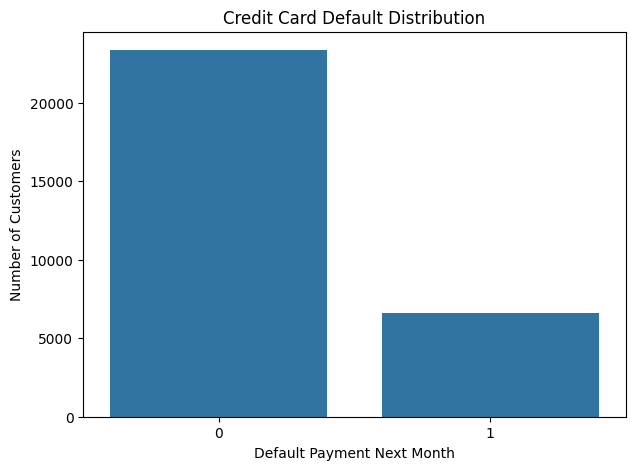


Feature Engineering Completed!

Feature Shape: (30000, 30)
Target Shape: (30000,)

Missing values after preprocessing:
0

Training Data Shape: (24000, 30)
Testing Data Shape: (6000, 30)

Feature Scaling Completed!

Logistic Regression Model Trained!

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Prediction Probabilities:
[0.12717048 0.17347814 0.15460496 0.11224311 0.0555166  0.34241589
 0.11634455 0.08862059 0.07248874 0.12735535]

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8103333333333333
Precision: 0.6620926243567753
Recall   : 0.2908816880180859
F1 Score : 0.4041884816753927
ROC-AUC  : 0.7395024182113058

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.66      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.65      6000
weighted avg       0.79      0.81      0.78      6000



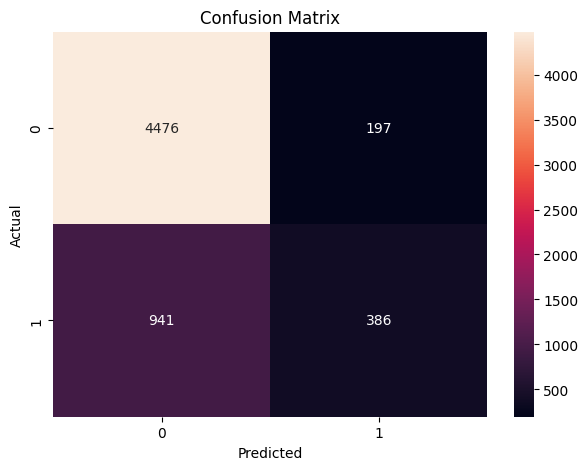

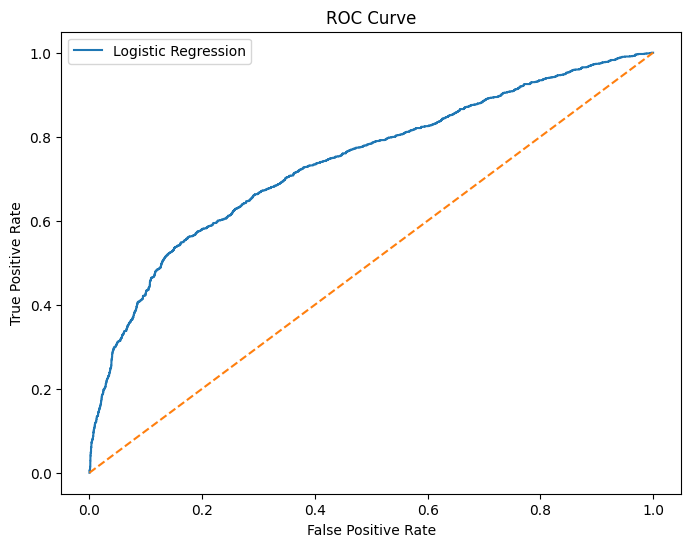


LOGISTIC REGRESSION COEFFICIENTS
                 Feature  Coefficient
28  NUM_DELAYED_PAYMENTS     0.808367
5                  PAY_0     0.351491
0              LIMIT_BAL    -0.269341
29    PAYMENT_BILL_RATIO    -0.175782
12             BILL_AMT2     0.159093
17              PAY_AMT1    -0.130807
11             BILL_AMT1    -0.115387
9                  PAY_5    -0.108894
18              PAY_AMT2    -0.108632
6                  PAY_2    -0.104523
13             BILL_AMT3     0.088297
16             BILL_AMT6    -0.073297
7                  PAY_3    -0.069217
1                    SEX    -0.064837
10                 PAY_6    -0.061814
8                  PAY_4    -0.059594
2              EDUCATION    -0.058590
4                    AGE     0.056282
25     TOTAL_PAYMENT_AMT    -0.055083
26       AVG_PAYMENT_AMT    -0.055083
3               MARRIAGE    -0.054445
14             BILL_AMT4     0.051470
15             BILL_AMT5    -0.030162
21              PAY_AMT5     0.028740
19              

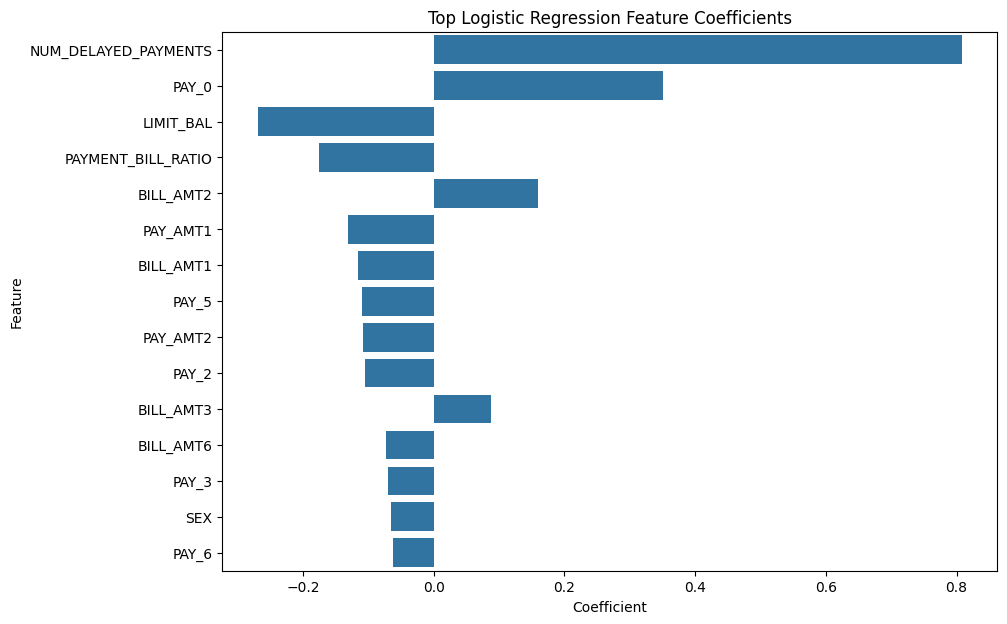


SINGLE CUSTOMER PREDICTION
Prediction: Customer is likely to NOT DEFAULT
Probability of Default: 0.12717047884221294

FULL LOGISTIC REGRESSION PIPELINE COMPLETED!

Final Results:
Accuracy : 0.8103
Precision: 0.6621
Recall   : 0.2909
F1 Score : 0.4042
ROC-AUC  : 0.7395


In [ ]:

# FULL LOGISTIC REGRESSION PIPELINE PROJECT
# UCI CREDIT CARD DEFAULT DATASET
# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("UCI_Credit_Card.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. BASIC DATA UNDERSTANDING
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 5. TARGET VARIABLE
# ============================================================

target = "default.payment.next.month"

print("\nTarget Variable:")
print(df[target].value_counts())

print("\nTarget Percentage:")
print(
    df[target].value_counts(normalize=True) * 100
)


# ============================================================
# 6. TARGET VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x=target,
    data=df
)

plt.title("Credit Card Default Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.show()


# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

# -------------------- BILL FEATURES --------------------------

bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

df["TOTAL_BILL_AMT"] = (
    df[bill_columns].sum(axis=1)
)

df["AVG_BILL_AMT"] = (
    df[bill_columns].mean(axis=1)
)


# -------------------- PAYMENT FEATURES -----------------------

payment_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df["TOTAL_PAYMENT_AMT"] = (
    df[payment_columns].sum(axis=1)
)

df["AVG_PAYMENT_AMT"] = (
    df[payment_columns].mean(axis=1)
)


# -------------------- REPAYMENT FEATURES ---------------------

pay_status_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df["AVG_REPAYMENT_STATUS"] = (
    df[pay_status_columns].mean(axis=1)
)

df["NUM_DELAYED_PAYMENTS"] = (
    df[pay_status_columns] > 0
).sum(axis=1)


# -------------------- PAYMENT-BILL RATIO ---------------------

df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)


print("\nFeature Engineering Completed!")


# ============================================================
# 8. SELECT FEATURES
# ============================================================

features = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",

    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",

    # Engineered features
    "TOTAL_BILL_AMT",
    "AVG_BILL_AMT",
    "TOTAL_PAYMENT_AMT",
    "AVG_PAYMENT_AMT",
    "AVG_REPAYMENT_STATUS",
    "NUM_DELAYED_PAYMENTS",
    "PAYMENT_BILL_RATIO"
]


X = df[features]

y = df[target]


print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ============================================================
# 9. CHECK FOR INFINITE / MISSING VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)


print("\nMissing values after preprocessing:")
print(X.isnull().sum().sum())


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ============================================================
# 11. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed!")


# ============================================================
# 12. CREATE LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ============================================================
# 13. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression Model Trained!")


# ============================================================
# 14. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_scaled
)

# Probability of class 1
y_probability = model.predict_proba(
    X_test_scaled
)[:, 1]


print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Prediction Probabilities:")
print(y_probability[:10])


# ============================================================
# 15. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n================================================")
print("LOGISTIC REGRESSION RESULTS")
print("================================================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# 18. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# ============================================================
# 19. FEATURE COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


print("\n================================================")
print("LOGISTIC REGRESSION COEFFICIENTS")
print("================================================")

print(
    coefficients[
        ["Feature", "Coefficient"]
    ]
)


# ============================================================
# 20. COEFFICIENT VISUALIZATION
# ============================================================

top_coefficients = coefficients.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=top_coefficients
)

plt.title("Top Logistic Regression Feature Coefficients")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()


# ============================================================
# 21. PREDICT A SINGLE CUSTOMER
# ============================================================

# Select the first customer from test data

sample_customer = X_test.iloc[[0]]

sample_customer_scaled = scaler.transform(
    sample_customer
)

sample_prediction = model.predict(
    sample_customer_scaled
)

sample_probability = model.predict_proba(
    sample_customer_scaled
)[0][1]


print("\n================================================")
print("SINGLE CUSTOMER PREDICTION")
print("================================================")

if sample_prediction[0] == 1:
    print("Prediction: Customer is likely to DEFAULT")
else:
    print("Prediction: Customer is likely to NOT DEFAULT")

print(
    "Probability of Default:",
    sample_probability
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FULL LOGISTIC REGRESSION PIPELINE COMPLETED!")
print("================================================")

print("\nFinal Results:")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))